In [38]:
%matplotlib inline
import numpy as np
import time
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
import heapq
import random

### 1. Warehouse Map

In [39]:
warehouse = np.array([
    [0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0],
    [0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0],
    [0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0],
    [0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0],
    [0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0],
    [0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0],
    [0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0],
    [0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0],
    [0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0],
    [0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0],
    [0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0]
])

### 2. Coordinate Validation

- จุดทางเข้า (Entrance) และทางออก (Exit) ต้องอยู่บนพื้นที่ทางเดิน (0)

- จุดหยิบสินค้า (Pickup points) ทั้งหมดต้องอยู่บนชั้นวางสินค้า (1)

In [40]:
def validate_points(warehouse, entrance, exit_point, pickup_points):
    if warehouse[entrance] != 0: raise ValueError("Entrance must be on walkway (0)")
    if warehouse[exit_point] != 0: raise ValueError("Exit must be on walkway (0)")
    for point in pickup_points:
        if warehouse[point] != 1: raise ValueError(f"Pickup point {point} must be on shelf (1)")

### 3. Random Pickup Point Generation

- ค้นหาพิกัดทั้งหมดในแผนที่ที่เป็นชั้นวางสินค้า (1)

- สุ่มเลือกตำแหน่งชั้นวางขึ้นมาให้ครบตามจำนวน n จุด โดยไม่ให้ซ้ำตำแหน่งกัน

- ใช้ค่า seed ในการสุ่ม เพื่อล็อกผลลัพธ์ให้ได้พิกัดเดิมเสมอทุกครั้งที่รันโปรแกรม

In [41]:
def generate_pickup_points(warehouse, n, seed=42):
    shelf_positions = list(zip(*np.where(warehouse == 1)))
    rng = np.random.default_rng(seed)
    selected_indices = rng.choice(len(shelf_positions), size=n, replace=False)
    return [shelf_positions[index] for index in selected_indices]

### 4. Warehouse Map Visualization

In [42]:
def plot_warehouse(warehouse, entrance, exit_point, pickup_points):
    rows, cols = warehouse.shape
    colors = ["#EAF6FF", "#4A4A4A"]
    warehouse_cmap = ListedColormap(colors)
    plt.figure(figsize=(12, 8))
    plt.imshow(warehouse, cmap=warehouse_cmap, origin="upper", interpolation="nearest")
    
    plt.scatter(entrance[1], entrance[0], color="#27AE60", s=220, edgecolors="black", zorder=3)
    plt.text(entrance[1], entrance[0], "IN", ha="center", va="center", color="white", fontweight="bold", fontsize=8, zorder=4)
    
    plt.scatter(exit_point[1], exit_point[0], color="#E74C3C", s=220, edgecolors="black", zorder=3)
    plt.text(exit_point[1], exit_point[0], "OUT", ha="center", va="center", color="white", fontweight="bold", fontsize=7, zorder=4)
    
    for index, point in enumerate(pickup_points, start=1):
        plt.scatter(point[1], point[0], color="#F1C40F", s=180, marker="s", edgecolors="black", zorder=3)
        plt.text(point[1], point[0], str(index), ha="center", va="center", fontweight="bold", color="black", zorder=4)

    plt.xticks(np.arange(-0.5, cols, 1), minor=True)
    plt.yticks(np.arange(-0.5, rows, 1), minor=True)
    plt.grid(which="minor", color="white", linestyle="-", linewidth=0.8)
    plt.title("Warehouse Map with Entrance, Exit and Pickup Points", fontsize=14, fontweight="bold")
    
    legend_elements = [
        Patch(facecolor="#EAF6FF", edgecolor="black", label="Walkway (0)"),
        Patch(facecolor="#4A4A4A", edgecolor="black", label="Shelf (1)"),
        plt.Line2D([0], [0], marker="o", color="w", label="Entrance", markerfacecolor="#27AE60", markeredgecolor="black", markersize=10),
        plt.Line2D([0], [0], marker="o", color="w", label="Exit", markerfacecolor="#E74C3C", markeredgecolor="black", markersize=10),
        plt.Line2D([0], [0], marker="s", color="w", label="Pickup Point", markerfacecolor="#F1C40F", markeredgecolor="black", markersize=10)
    ]
    
    plt.legend(handles=legend_elements, loc="upper center", bbox_to_anchor=(0.5, -0.05), ncol=5)
    plt.show()

### 5. Initialize Coordinates and Display Map

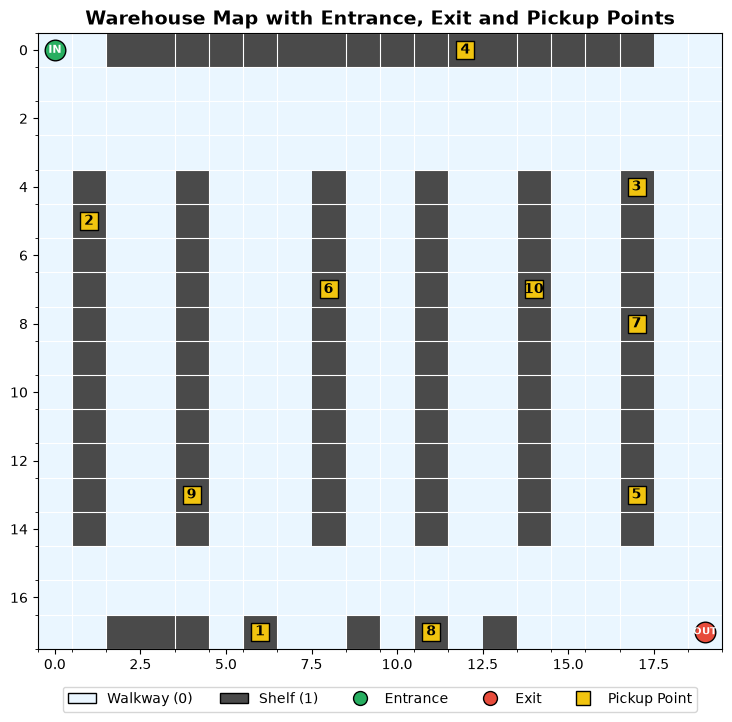

In [ ]:
entrance = (0, 0)
exit_point = (17, 19)
n = 10

pickup_points = generate_pickup_points(warehouse=warehouse, n=n, seed=20)

validate_points(warehouse, entrance, exit_point, pickup_points)  
plot_warehouse(warehouse, entrance, exit_point, pickup_points) 

### 6. Print Pickup Coordinates

In [44]:
print("Entrance:", entrance)
print("Exit:", exit_point)
for index, point in enumerate(pickup_points, start=1):
    print(f"  Pickup {index}: ({int(point[0])}, {int(point[1])})")

Entrance: (0, 0)
Exit: (17, 19)
  Pickup 1: (17, 6)
  Pickup 2: (5, 1)
  Pickup 3: (4, 17)
  Pickup 4: (0, 12)
  Pickup 5: (13, 17)
  Pickup 6: (7, 8)
  Pickup 7: (8, 17)
  Pickup 8: (17, 11)
  Pickup 9: (13, 4)
  Pickup 10: (7, 14)
